In [33]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [34]:
device = "cpu"

In [35]:
class MyNeuralNet(nn.Module):
    def __init__(self, layers, size_list):
        super().__init__()
        self.input_size, self.hidden_size, self.output_size = size_list

        self.layers = nn.ModuleList()
        
        self.layers.append(nn.Linear(self.input_size, self.hidden_size))
        self.out = nn.Linear(self.hidden_size, self.output_size)

        for _ in range(layers - 2):
            self.layers.append(nn.Linear(self.hidden_size, self.hidden_size))
        
    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        return self.out(x)

In [36]:
def make_spirals(n_samples=300, noise=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    n = n_samples // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi
    
    r_a = 2 * theta + np.pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    data_a += np.random.randn(n, 2) * noise
    
    r_b = -2 * theta - np.pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    data_b += np.random.randn(n, 2) * noise
    
    X = np.vstack([data_a, data_b])
    y = np.zeros(n_samples, dtype=int)
    y[n:] = 1
    
    return X, y


In [37]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

X, y = make_spirals(n_samples=3000, noise=1.4, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

len(train_loader)

9

In [39]:
model = MyNeuralNet(7,[2,16,1])
model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
epochs = 2000

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() 
    train_loss /= len(train_loader)
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss:.4f}")
    
print("Final Loss:", train_loss)

Epoch 0, Loss: 0.6817
Epoch 50, Loss: 0.0320
Epoch 100, Loss: 0.0426
Epoch 150, Loss: 0.0334
Epoch 200, Loss: 0.0382
Epoch 250, Loss: 0.0437
Epoch 300, Loss: 0.0331
Epoch 350, Loss: 0.0331
Epoch 400, Loss: 0.0432
Epoch 450, Loss: 0.0250
Epoch 500, Loss: 0.0279
Epoch 550, Loss: 0.0398
Epoch 600, Loss: 0.0313
Epoch 650, Loss: 0.0270
Epoch 700, Loss: 0.0342
Epoch 750, Loss: 0.0232
Epoch 800, Loss: 0.0294
Epoch 850, Loss: 0.0223
Epoch 900, Loss: 0.0337
Epoch 950, Loss: 0.0231
Epoch 1000, Loss: 0.0268
Epoch 1050, Loss: 0.0254
Epoch 1100, Loss: 0.0217
Epoch 1150, Loss: 0.0269
Epoch 1200, Loss: 0.0231
Epoch 1250, Loss: 0.0277
Epoch 1300, Loss: 0.0246
Epoch 1350, Loss: 0.0216
Epoch 1400, Loss: 0.0224
Epoch 1450, Loss: 0.0237
Epoch 1500, Loss: 0.0222
Epoch 1550, Loss: 0.0317
Epoch 1600, Loss: 0.0183
Epoch 1650, Loss: 0.0226
Epoch 1700, Loss: 0.0201
Epoch 1750, Loss: 0.0259
Epoch 1800, Loss: 0.0193
Epoch 1850, Loss: 0.0170
Epoch 1900, Loss: 0.0140
Epoch 1950, Loss: 0.0146
Final Loss: 0.030327450

In [40]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()
test_loss /= len(test_loader)
print(f"Train Loss={train_loss:.4f},\nTest Loss={test_loss:.4f}")

Train Loss=0.0303,
Test Loss=0.0886


In [41]:
def evaluate(loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

print("Train Acc:", evaluate(train_loader) * 100)
print("Test Acc:", evaluate(test_loader) * 100)

Train Acc: 99.09523809523809
Test Acc: 97.66666666666667


In [42]:
def plot_decision_boundary(model, X, y):
    model.eval()
    
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    grid = grid.to(device)
    
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits)
    
    Z = probs.cpu().reshape(xx.shape).numpy()
    
    plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap="coolwarm", edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

In [43]:
def plot_3d_surface(model, X, y):
    model.eval()

    # Create grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    grid = grid.to(device)

    # Get predictions
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits)

    Z = probs.cpu().reshape(xx.shape).numpy()

    # Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(xx, yy, Z, alpha=0.6)
    
    # Scatter original points
    ax.scatter(
        X[:, 0], X[:, 1], y.squeeze(),
        c=y.squeeze(), cmap='coolwarm', edgecolor='k'
    )

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Probability")
    ax.set_title("3D Decision Surface")

    plt.show()

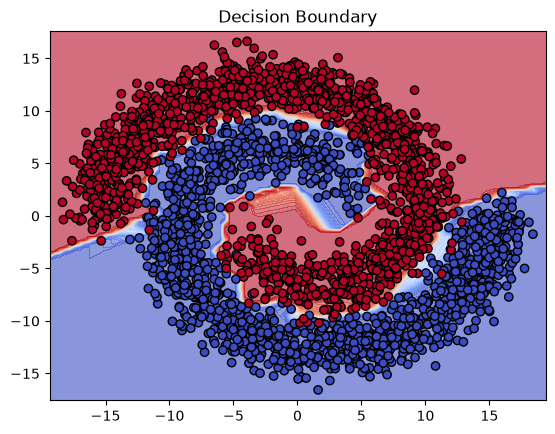

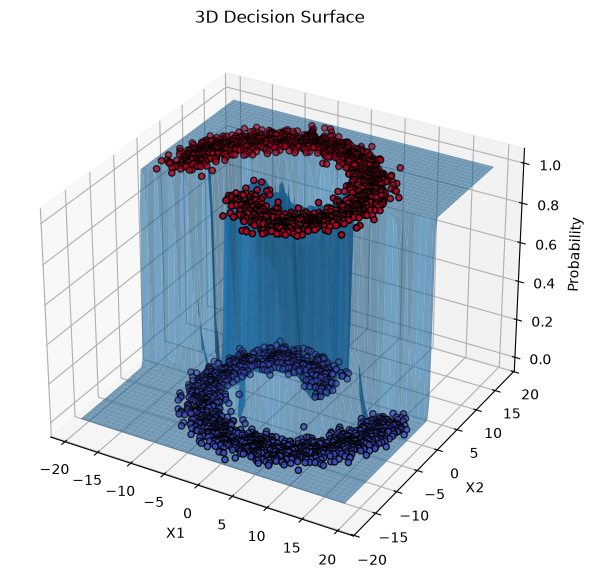

In [44]:
plot_decision_boundary(model, X.cpu().numpy(), y.cpu().numpy())
plot_3d_surface(model, X.cpu().numpy(), y.cpu().numpy())

In [45]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad)
        print()

layers.0.weight tensor([[-0.0013,  0.0318],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0007,  0.0104],
        [ 0.3153, -0.1490],
        [-0.2138,  0.0928],
        [ 0.1223, -0.0546],
        [ 0.0039,  0.0059],
        [ 0.2225, -0.1005],
        [-0.1655,  0.0754],
        [ 0.0013, -0.0008],
        [ 0.0000,  0.0000],
        [ 0.2125, -0.1038],
        [ 0.2233, -0.0949],
        [-0.0047,  0.0142],
        [ 0.2700, -0.1192]])

layers.0.bias tensor([-0.0052,  0.0000,  0.0000, -0.0015,  0.0268, -0.0171,  0.0099, -0.0008,
         0.0183, -0.0136, -0.0001,  0.0000,  0.0189,  0.0176, -0.0016,  0.0219])

layers.1.weight tensor([[-8.8720e-05,  0.0000e+00,  0.0000e+00,  1.1055e-06, -1.7494e-04,
         -1.9173e-04, -9.9921e-05, -3.3723e-05, -1.7927e-04, -2.9340e-04,
          0.0000e+00,  0.0000e+00, -2.9175e-05, -1.4972e-04, -6.6773e-05,
         -2.1042e-04],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00, -3.2169e-05,
         -8.7771e-07,  